<a href="https://colab.research.google.com/github/mhabibier/scikit-learn-cookbook/blob/main/04_Distance_Metrics_and_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 — Building Models with Distance Metrics and Nearest Neighbors

**Nama:** Muhammad Habibie Rabbani  
**Kelas:** TK-47-04  
**Program Studi:** Teknik Komputer, Telkom University

**Referensi utama:** John Sukup, *scikit-learn Cookbook*, edisi ketiga, Packt Publishing (2025), Chapter 4. Kode diadaptasi dari [notebook dan solusi latihan resmi penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_4). Urutan metode dan dataset mengacu pada sumber tersebut; penjelasan bahasa Indonesia serta pemeriksaan tambahan disusun untuk pembelajaran. Lisensi kode sumber terdapat dalam `THIRD_PARTY_NOTICES.md`.

## Tujuan pembelajaran

1. Menjelaskan cara KNN memakai tetangga terdekat dan pengaruh skala fitur.
2. Menghitung Euclidean, Manhattan, dan Minkowski serta membandingkan metrik secara terukur.
3. Menentukan k, weights, dan distance metric dengan GridSearchCV di dalam pipeline.
4. Membaca accuracy, precision, recall, F1, confusion matrix, serta learning curve.
5. Menyelesaikan tiga latihan buku dan mengenali keterbatasan generalisasi hasil.

## Peta reproduksi dan adaptasi

| Resep/latihan sumber | Bagian notebook | Reproduksi dan penyesuaian |
|---|---|---|
| KNN dasar pada Iris | 2–3 | k=3 tanpa scaling sebagai resep dasar; split ditambah stratifikasi |
| Distance metrics | 4 | Noisy circles dan checkerboard; seed eksplisit, nama dataset diperbaiki |
| Tuning KNN | 5 | Grid k/weights/metric buku, dengan scaler di dalam pipeline |
| Evaluasi KNN | 6 | CV, learning curve, confusion matrix, classification report; tambahan nested CV |
| Latihan 1 | 7 | Breast Cancer, k=5, stratified split dan baseline |
| Latihan 2 | 8 | Data sintetis 20 fitur, 3 kelas; GridSearchCV yang aman dari leakage |
| Latihan 3 | 9 | Data sintetis 15 fitur, 3 kelas; laporan evaluasi lengkap |
| Tambahan pembelajaran | 10 | KNN regression sebagai pembanding voting vs rata-rata |

**Penyesuaian:** perbandingan metrik dilakukan melalui CV pada training; tidak ada klaim bahwa Manhattan/Euclidean pasti menang berdasarkan bentuk data. Accuracy 100% pada kelas tertentu bukan bukti tunggal overfitting. Seluruh pilihan tuning didasarkan pada training.

**Cara menjalankan:** buka notebook ini sendiri, lalu jalankan semua sel dari atas ke bawah pada kernel baru. Seluruh dataset chapter ini tersedia dalam scikit-learn atau dibuat secara sintetis, sehingga tidak membutuhkan unduhan data. Angka hasil dapat sedikit berubah antarversi pustaka. Visualisasi seluruh data diberi label sebagai eksplorasi; evaluasi prediktif memakai data test yang terpisah.

## 1. Lingkungan dan reproducibility

Seed mengendalikan pembagian data dan algoritma stokastik. Versi pustaka dicetak supaya hasil bisa ditelusuri. Seed yang sama tidak menjamin hasil identik pada semua perangkat dan versi. Setiap notebook menggunakan nama variabel tersendiri dan tidak bergantung pada eksekusi chapter lain.

In [1]:
%matplotlib inline
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

RANDOM_STATE = 2024
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
COLORS = ["#2563A6", "#D97732", "#47916F", "#885DA6", "#C54B62"]
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__, "| pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__, "| Matplotlib:", matplotlib.__version__)
print("Random state:", RANDOM_STATE)

Python: 3.12.14
NumPy: 2.3.5 | pandas: 2.2.3
scikit-learn: 1.8.0 | Matplotlib: 3.10.8
Random state: 2024


## 2. Data Iris dan pemeriksaan awal

Iris berisi 150 pengukuran bunga, empat fitur numerik, dan tiga kelas yang seimbang. Semua fitur berada dalam satuan sentimeter, tetapi rentang dan variasinya tetap berbeda. KNN menghitung jarak sehingga perbedaan skala dapat mengubah tetangga yang terpilih.

Audit duplikasi dilakukan pada fitur dan fitur+target. Duplikat tidak otomatis dihapus: pengukuran yang dibulatkan dapat sama walaupun berasal dari bunga berbeda. Untuk dataset operasional, identitas objek/subjek perlu diperiksa dan split harus berbasis grup bila beberapa baris berasal dari objek yang sama. Identitas tersebut tidak tersedia di benchmark Iris.

In [2]:
from sklearn.datasets import load_iris, make_circles, load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

iris = load_iris(as_frame=True)
X_iris, y_iris = iris.data, iris.target
print("Iris shape:", X_iris.shape)
print("Missing:", int(X_iris.isna().sum().sum()),
      "Infinite:", int(np.isinf(X_iris.to_numpy()).sum()),
      "Duplicate feature rows:", int(X_iris.duplicated().sum()),
      "Duplicate feature+target rows:", int(iris.frame.duplicated().sum()))
print("Class counts:", y_iris.value_counts().sort_index().to_dict())
display(X_iris.describe().loc[["min", "max", "std"]].round(3))
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=RANDOM_STATE, stratify=y_iris)
assert set(X_train.index).isdisjoint(X_test.index)
assert np.isfinite(X_train.to_numpy()).all()
print("Training:", X_train.shape, "| test:", X_test.shape)
# Hitung overlap untuk transparansi, jangan menyembunyikan jika ada.
train_rows = set(map(tuple, X_train.to_numpy()))
test_rows = set(map(tuple, X_test.to_numpy()))
print("Exact feature rows shared between train/test:", len(train_rows & test_rows))

Iris shape: (150, 4)
Missing: 0 Infinite: 0 Duplicate feature rows: 1 Duplicate feature+target rows: 1
Class counts: {0: 50, 1: 50, 2: 50}
Training: (120, 4) | test: (30, 4)
Exact feature rows shared between train/test: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
min,4.300,2.000,1.000,0.100
max,7.900,4.400,6.900,2.500
std,0.828,0.436,1.765,0.762


## 3. Cara kerja K-Nearest Neighbors

Untuk observasi baru $x$, KNN mencari $k$ sampel training dengan jarak terkecil. Klasifikasi menggunakan suara mayoritas atau suara berbobot jarak; regresi menggunakan rata-rata atau rata-rata berbobot target tetangga.

KNN disebut *lazy learner*: `fit()` terutama menyimpan data serta struktur pencarian, sementara banyak komputasi terjadi saat prediksi. KNN bersifat nonparametrik, tetapi tetap bergantung pada asumsi bahwa tetangga menurut metrik yang dipilih memiliki target yang mirip. Ia sensitif terhadap skala, fitur tak relevan, outlier, dan dimensi tinggi. Biaya prediksi dan penyimpanan meningkat bersama ukuran data.

Nilai $k$ kecil menghasilkan batas keputusan yang lebih fleksibel dan sensitif noise; $k$ besar lebih halus dan bisa mengabaikan pola lokal. Tidak ada nilai $k$ terbaik untuk semua dataset. Resep dasar menggunakan $k=3$ tanpa scaling sebagaimana contoh buku; versi tuning nanti memakai pipeline.

In [3]:
basic_knn = KNeighborsClassifier(n_neighbors=3)
basic_knn.fit(X_train, y_train)
basic_pred = basic_knn.predict(X_test)
print("Basic KNN, k=3 (unscaled), test accuracy:", round(accuracy_score(y_test, basic_pred), 4))

# Telusuri prediksi satu sampel test untuk memahami voting.
distances, positions = basic_knn.kneighbors(X_test.iloc[[0]])
neighbor_details = pd.DataFrame({
    "training row index": X_train.index.to_numpy()[positions[0]],
    "distance": distances[0],
    "class": y_train.to_numpy()[positions[0]],
})
display(neighbor_details)
print("True class:", int(y_test.iloc[0]), "| predicted class:", int(basic_pred[0]))

Basic KNN, k=3 (unscaled), test accuracy: 0.9333
True class: 0 | predicted class: 0


,training row index,distance,class
0,38,0.714143,0
1,45,0.768115,0
2,13,0.781025,0


### Analisis resep dasar

Tabel tetangga memperlihatkan bagaimana prediksi ditentukan. Jarak dihitung dari fitur training, sedangkan label test dipakai hanya untuk evaluasi. Skor resep ini dicatat sebagai konfigurasi tetap dari buku dan tidak dipakai untuk memilih parameter grid berikutnya. Karena test hanya 30 observasi, satu kesalahan saja mengubah accuracy sekitar 3,3 poin persentase; skor tinggi perlu dibaca bersama ukuran sampelnya.

## 4. Distance metrics

Minkowski dengan parameter p merangkum dua metrik umum:

$$d_p(x,z)=\left(\sum_{j=1}^{m}|x_j-z_j|^p\right)^{1/p}.$$

Untuk **p=1**, hasilnya Manhattan (jumlah selisih absolut). Untuk **p=2**, hasilnya Euclidean (jarak garis lurus). `metric="minkowski"` dengan default `p=2` sama dengan Euclidean; membandingkannya sebagai dua metode yang berbeda akan menyesatkan. Demonstrasi numerik juga menyertakan p=3 agar efek perubahan p terlihat.

In [4]:
from sklearn.metrics import pairwise_distances
point_a = np.array([[0.0, 0.0]])
point_b = np.array([[3.0, 4.0]])
distance_rows = []
for metric, p in [("manhattan", None), ("euclidean", None), ("minkowski", 2), ("minkowski", 3)]:
    kwargs = {} if p is None else {"p":p}
    d = pairwise_distances(point_a, point_b, metric=metric, **kwargs)[0, 0]
    distance_rows.append({"metric":metric, "p":p, "distance":d})
display(pd.DataFrame(distance_rows).round(4))
assert np.isclose(distance_rows[1]["distance"], 5)
assert np.isclose(distance_rows[0]["distance"], 7)
assert np.isclose(distance_rows[1]["distance"], distance_rows[2]["distance"])

,metric,p,distance
0,manhattan,NaN,7.0000
1,euclidean,NaN,5.0000
2,minkowski,2.0,5.0000
3,minkowski,3.0,4.4979


### Reproduksi noisy circles dan checkerboard

Dataset kedua pada sumber diberi nama variabel `moons`, tetapi geometri yang dibuat adalah **checkerboard**. Notebook ini memakai nama yang sesuai. Seed pada `make_circles` ditetapkan agar noise dapat direproduksi.

Kedua dataset memiliki fitur pada satuan yang sebanding. Untuk mengikuti demonstrasi geometri, KNN di sini menggunakan koordinat asli tanpa scaling. Metrik dibandingkan dengan stratified CV hanya pada bagian training. Plot test menunjukkan posisi sampel yang disisihkan, sementara label test tidak digunakan untuk memilih metrik.

Noisy circles samples: 300 | training/test: 240 60
Checkerboard samples: 289 | training/test: 231 58


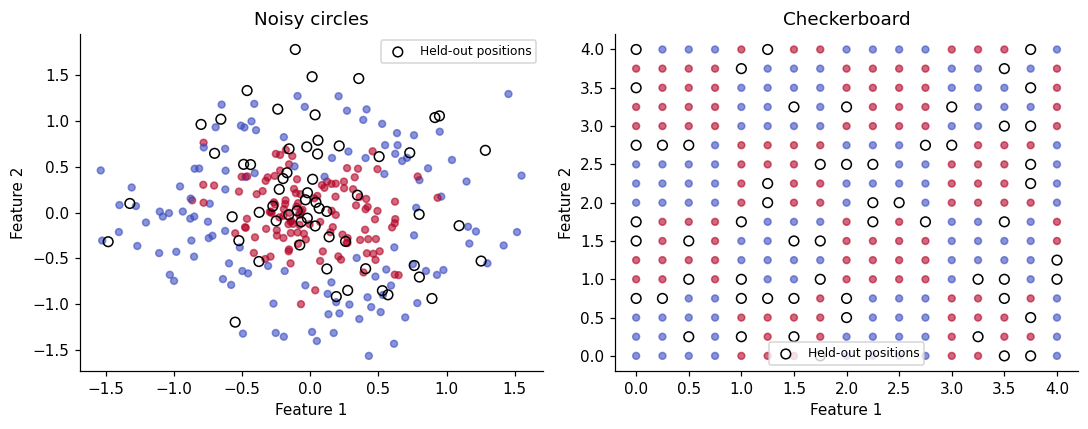

,dataset,metric,CV mean,CV std
0,Noisy circles,Euclidean,0.8375,0.0276
1,Noisy circles,Manhattan,0.8333,0.0295
2,Noisy circles,Minkowski p=2,0.8375,0.0276
3,Noisy circles,Minkowski p=3,0.8333,0.0295
4,Checkerboard,Euclidean,0.7749,0.0575
5,Checkerboard,Manhattan,0.7924,0.0802
6,Checkerboard,Minkowski p=2,0.7749,0.0575
7,Checkerboard,Minkowski p=3,0.7749,0.0575


In [5]:
X_circles, y_circles = make_circles(n_samples=300, noise=0.3, factor=0.3,
                                    random_state=RANDOM_STATE)
axis = np.linspace(0, 4, int(np.sqrt(300)))
xx, yy = np.meshgrid(axis, axis)
X_checker = np.column_stack([xx.ravel(), yy.ravel()])
y_checker = ((np.floor(xx.ravel()) + np.floor(yy.ravel())) % 2).astype(int)
metric_configs = [("Euclidean", {"metric":"euclidean"}),
                  ("Manhattan", {"metric":"manhattan"}),
                  ("Minkowski p=2", {"metric":"minkowski", "p":2}),
                  ("Minkowski p=3", {"metric":"minkowski", "p":3})]
metric_rows = []
metric_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, label, X, y in zip(axes, ["Noisy circles", "Checkerboard"],
                          [X_circles, X_checker], [y_circles, y_checker]):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                       random_state=RANDOM_STATE, stratify=y)
    print(label, "samples:", len(X), "| training/test:", len(Xtr), len(Xte))
    for metric_name, kwargs in metric_configs:
        scores = cross_val_score(KNeighborsClassifier(n_neighbors=3, **kwargs),
                                 Xtr, ytr, cv=metric_cv, scoring="accuracy")
        metric_rows.append({"dataset":label, "metric":metric_name,
                            "CV mean":scores.mean(), "CV std":scores.std()})
    ax.scatter(*Xtr.T, c=ytr, cmap="coolwarm", s=20, alpha=0.6)
    ax.scatter(*Xte.T, facecolors="none", edgecolors="black", s=40, label="Held-out positions")
    ax.set(title=label, xlabel="Feature 1", ylabel="Feature 2")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
metric_results = pd.DataFrame(metric_rows)
display(metric_results.round(4))
for label in metric_results["dataset"].unique():
    subset = metric_results[metric_results["dataset"] == label].set_index("metric")
    assert np.isclose(subset.loc["Euclidean", "CV mean"], subset.loc["Minkowski p=2", "CV mean"])

### Analisis metrik jarak

Angka Euclidean dan Minkowski p=2 seharusnya sama karena definisinya sama. Manhattan tidak dijamin menang pada checkerboard, dan Euclidean tidak dijamin menang pada circles: hasil juga dipengaruhi noise, jumlah tetangga, pembagian fold, dan sampel. Checkerboard pada kode berisi 17×17=289 titik, bukan tepat 300, karena jumlah titik per sumbu dibulatkan ke bawah.

## 5. Tuning KNN menggunakan GridSearchCV

Grid dari buku mencakup lima nilai k, dua jenis weights, dan dua metrik: 20 kandidat. `weights="uniform"` memberi suara sama; `"distance"` memberi pengaruh lebih besar pada tetangga dekat. `StandardScaler` berada **di dalam Pipeline** supaya mean dan simpangan baku tidak dipelajari dari bagian validation.

Training 120 baris dibagi menjadi lima fold. Setiap kandidat dilatih pada empat fold dan dievaluasi pada fold tersisa, lalu nilai dirata-ratakan. `refit=True` melatih kandidat terpilih kembali pada seluruh training. Test tidak diberikan kepada GridSearchCV. CV tidak otomatis mengacak urutan; `shuffle=True` ditetapkan secara eksplisit.

In [6]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])
param_grid = {
    "knn__n_neighbors":[3, 5, 7, 9, 11],
    "knn__weights":["uniform", "distance"],
    "knn__metric":["euclidean", "manhattan"],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(knn_pipeline, param_grid, cv=cv, scoring="accuracy",
                           n_jobs=1, refit=True, error_score="raise")
grid_search.fit(X_train, y_train)
print("Candidate configurations:", len(grid_search.cv_results_["params"]))
print("Best parameters:", grid_search.best_params_)
print("Best mean CV accuracy:", round(grid_search.best_score_, 4))
cv_table = pd.DataFrame(grid_search.cv_results_)
display(cv_table[["param_knn__n_neighbors", "param_knn__weights", "param_knn__metric",
                  "mean_test_score", "std_test_score", "rank_test_score"]]
        .sort_values("rank_test_score").head(8).round(4))

Candidate configurations: 20
Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best mean CV accuracy: 0.975


,param_knn__n_neighbors,param_knn__weights,param_knn__metric,mean_test_score,std_test_score,rank_test_score
1,3,distance,euclidean,0.9750,0.0204,1
3,5,distance,euclidean,0.9750,0.0204,1
4,7,uniform,euclidean,0.9750,0.0204,1
11,3,distance,manhattan,0.9750,0.0204,1
13,5,distance,manhattan,0.9750,0.0204,1
15,7,distance,manhattan,0.9667,0.0312,6
9,11,distance,euclidean,0.9667,0.0312,6
5,7,distance,euclidean,0.9667,0.0312,6


## 6. Mengevaluasi KNN

Accuracy menghitung proporsi seluruh prediksi benar. Untuk suatu kelas, precision adalah TP/(TP+FP), recall adalah TP/(TP+FN), dan F1 adalah rata-rata harmonik precision dan recall. Macro-F1 memberi bobot sama pada setiap kelas; weighted-F1 memakai jumlah observasi sebagai bobot. Balanced accuracy merata-ratakan recall per kelas.

Nilai terbaik dari grid cenderung optimistis karena digunakan sekaligus untuk memilih parameter. Tambahan **nested CV** berikut menilai prosedur tuning: outer fold disisihkan, sementara pencarian parameter hanya berlangsung di inner fold. Seluruh nested CV tetap berada di data training, sehingga test akhir tetap terpisah.

In [7]:
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=43)
nested_search = GridSearchCV(knn_pipeline, param_grid, cv=inner_cv, scoring="accuracy",
                             n_jobs=1, error_score="raise")
nested_scores = cross_val_score(nested_search, X_train, y_train, cv=outer_cv,
                                scoring="accuracy", error_score="raise")
print("Nested CV accuracy (training only):", nested_scores.round(4))
print("Nested CV mean ± std:", round(nested_scores.mean(), 4), "±", round(nested_scores.std(), 4))

Nested CV accuracy (training only): [0.975 0.925 0.975]
Nested CV mean ± std: 0.9583 ± 0.0236


### Learning curve

Learning curve memperlihatkan perubahan skor training dan validation ketika jumlah sampel training ditambah. Jarak besar antara keduanya dapat menunjukkan varians tinggi; keduanya rendah dapat menunjukkan bias tinggi atau fitur kurang informatif. Kurva bukan bukti tunggal dan perlu dibaca bersama variasi fold.

Ukuran terkecil dimulai dari 30% supaya lebih besar daripada k maksimum. Karena parameter telah dipilih pada data training yang sama, kurva ini dipakai sebagai diagnosis deskriptif. Estimasi prosedur seleksi yang lebih jujur diberikan oleh nested CV di atas.

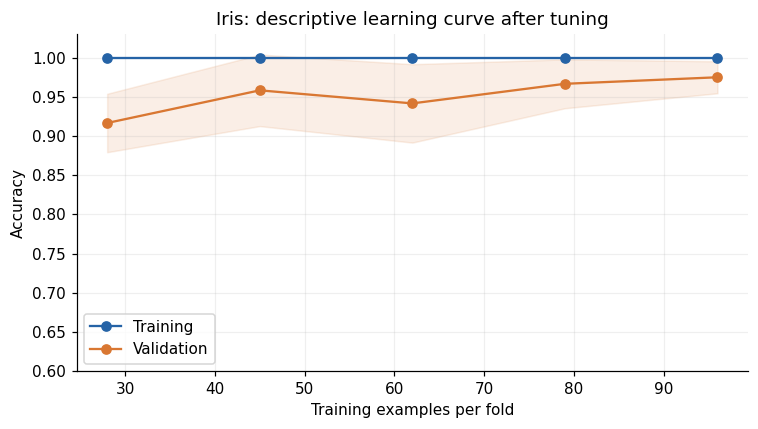

In [8]:
sizes, train_scores, validation_scores = learning_curve(
    grid_search.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.3, 1.0, 5), cv=cv, scoring="accuracy",
    shuffle=True, random_state=RANDOM_STATE, error_score="raise", n_jobs=1)
fig, ax = plt.subplots(figsize=(7, 4))
for scores, label, color in [(train_scores,"Training",COLORS[0]),
                              (validation_scores,"Validation",COLORS[1])]:
    mean, std = scores.mean(axis=1), scores.std(axis=1)
    ax.plot(sizes, mean, "o-", color=color, label=label)
    ax.fill_between(sizes, mean-std, mean+std, color=color, alpha=0.12)
ax.set(xlabel="Training examples per fold", ylabel="Accuracy", ylim=(0.6, 1.03),
       title="Iris: descriptive learning curve after tuning")
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



,model,accuracy,balanced accuracy,macro-F1
0,KNN selected by training CV,0.9333,0.9333,0.9333
1,Most-frequent baseline,0.3333,0.3333,0.1667


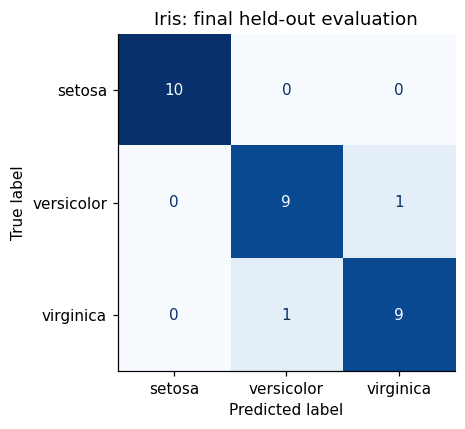

In [9]:
best_pred = grid_search.predict(X_test)
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
final_metrics = pd.DataFrame([
    {"model":name, "accuracy":accuracy_score(y_test, pred),
     "balanced accuracy":balanced_accuracy_score(y_test, pred),
     "macro-F1":f1_score(y_test, pred, average="macro")}
    for name,pred in [("KNN selected by training CV",best_pred),
                      ("Most-frequent baseline",dummy.predict(X_test))]
])
display(final_metrics.round(4))
print(classification_report(y_test, best_pred, labels=[0,1,2],
                            target_names=iris.target_names, zero_division=0))
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=iris.target_names,
                                        ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Iris: final held-out evaluation")
plt.tight_layout(); plt.show()

### Analisis hasil Iris

Confusion matrix memakai **baris = kelas sebenarnya** dan **kolom = prediksi**. Perhatikan jumlah kesalahan di luar diagonal dan bandingkan metrik dengan baseline. Accuracy 100% pada satu kelas atau pada 30 sampel test **tidak cukup membuktikan overfitting**. Overfitting perlu dinilai melalui perbedaan train/validation, pengulangan pada data lain, dan kompleksitas model.

Iris kecil dan relatif mudah dipisahkan. Skor tinggi di sini tidak berarti KNN pasti cocok untuk data berdimensi tinggi atau data dengan noise besar. Duplikasi pengukuran serta tidak tersedianya ID objek membatasi audit independensi sampel yang bisa dilakukan.

## 7. Latihan 1 — Klasifikasi biner Breast Cancer

Mengikuti solusi buku, digunakan 30 fitur numerik dan KNN k=5. Split 80:20 ditambah stratifikasi, kemudian scaler dan KNN dilatih melalui pipeline. Label **0=malignant** dan **1=benign**. Karena salah mengklasifikasikan malignant sebagai benign merupakan jenis kesalahan tertentu, recall kelas 0 dicetak secara eksplisit. Contoh ini merupakan latihan benchmark, belum merupakan validasi penggunaan klinis.

Shape: (569, 30) | missing: 0 | duplicate rows: 0
Labels: {0: np.str_('malignant'), 1: np.str_('benign')}
Class counts: {0: 212, 1: 357}
KNN test accuracy: 0.9561
Baseline test accuracy: 0.6316
Malignant recall (positive label=0): 0.9286
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Malignant predicted benign: 3


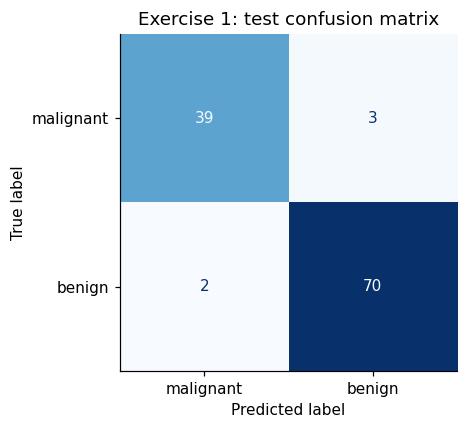

In [10]:
from sklearn.metrics import recall_score
cancer = load_breast_cancer(as_frame=True)
Xc, yc = cancer.data, cancer.target
print("Shape:", Xc.shape, "| missing:", int(Xc.isna().sum().sum()),
      "| duplicate rows:", int(Xc.duplicated().sum()))
print("Labels:", dict(enumerate(cancer.target_names)))
print("Class counts:", yc.value_counts().sort_index().to_dict())
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc)
cancer_model = Pipeline([("scaler", StandardScaler()),
                         ("knn", KNeighborsClassifier(n_neighbors=5))])
cancer_model.fit(Xc_train, yc_train)
cancer_pred = cancer_model.predict(Xc_test)
cancer_baseline = DummyClassifier(strategy="most_frequent").fit(Xc_train, yc_train)
print("KNN test accuracy:", round(accuracy_score(yc_test, cancer_pred), 4))
print("Baseline test accuracy:", round(accuracy_score(yc_test, cancer_baseline.predict(Xc_test)), 4))
print("Malignant recall (positive label=0):", round(recall_score(yc_test, cancer_pred, pos_label=0), 4))
print(classification_report(yc_test, cancer_pred, target_names=cancer.target_names, zero_division=0))
cancer_cm = confusion_matrix(yc_test, cancer_pred, labels=[0,1])
print("Malignant predicted benign:", cancer_cm[0,1])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cancer_cm, display_labels=cancer.target_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Exercise 1: test confusion matrix")
plt.tight_layout(); plt.show()

### Analisis latihan 1

Bandingkan accuracy terhadap baseline mayoritas agar model tidak dinilai hanya dari angka besar. Recall malignant secara khusus menghitung bagian malignant yang berhasil dikenali. Nilai `zero_division=0` membuat laporan terdefinisi jika suatu kelas tidak pernah diprediksi; itu tidak menghapus kegagalan model. Hyperparameter k=5 ditetapkan dari resep buku, bukan dicari dengan mencoba berulang pada test.

## 8. Latihan 2 — Grid search pada data sintetis multikelas

Generator mengikuti sumber: 1.000 sampel, 20 fitur, 15 informative, lima redundant, dan tiga kelas dengan seed 42. Label sintetis tidak memiliki makna dunia nyata. Semua preprocessing masuk dalam pipeline di GridSearchCV; melakukan scaling sekali pada seluruh training sebelum CV akan membocorkan informasi antar-fold.

In [11]:
Xg, yg = make_classification(n_samples=1000, n_features=20, n_informative=15,
                              n_redundant=5, n_classes=3, random_state=42)
Xg = pd.DataFrame(Xg, columns=[f"feature_{i}" for i in range(20)])
yg = pd.Series(yg)
print("Shape:", Xg.shape, "| missing:", int(Xg.isna().sum().sum()),
      "| duplicates:", int(Xg.duplicated().sum()))
print("Class counts:", yg.value_counts().sort_index().to_dict())
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    Xg, yg, test_size=0.2, random_state=42, stratify=yg)
exercise_search = GridSearchCV(knn_pipeline, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy", n_jobs=1, error_score="raise")
exercise_search.fit(Xg_train, yg_train)
print("Best parameters:", exercise_search.best_params_)
print("Best mean CV accuracy:", round(exercise_search.best_score_, 4))
grid_pred = exercise_search.predict(Xg_test)
print("Test accuracy:", round(accuracy_score(yg_test, grid_pred), 4))
print("Test macro-F1:", round(f1_score(yg_test, grid_pred, average="macro"), 4))
grid_baseline = DummyClassifier(strategy="most_frequent").fit(Xg_train, yg_train)
print("Baseline test accuracy:", round(accuracy_score(yg_test, grid_baseline.predict(Xg_test)), 4))
print(classification_report(yg_test, grid_pred, zero_division=0))

Shape: (1000, 20) | missing: 0 | duplicates: 0
Class counts: {0: 333, 1: 331, 2: 336}
Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best mean CV accuracy: 0.8588
Test accuracy: 0.885
Test macro-F1: 0.885
Baseline test accuracy: 0.335
              precision    recall  f1-score   support

           0       0.94      0.90      0.92        67
           1       0.86      0.92      0.89        66
           2       0.86      0.84      0.85        67

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.88       200



### Analisis latihan 2

Parameter terbaik hanya berlaku bagi data training, grid, dan fold yang digunakan. Mean CV dan skor test tidak harus sama karena dihitung dari sampel berbeda. Fitur redundant membuat sebagian koordinat saling terkait; standardisasi menyamakan skala marginal tetapi tidak menghilangkan korelasi tersebut. Nilai k terbaik tidak boleh disalin sebagai aturan umum untuk dataset lain.

## 9. Latihan 3 — Evaluasi KNN pada 15 fitur

Latihan sumber memakai dataset berbeda: 1.000 sampel, 15 fitur, sepuluh informative, lima redundant, dan tiga kelas. KNN k=5 ditetapkan sejak awal. Laporan menyertakan support kelas supaya pembaca tahu jumlah observasi yang mendasari precision, recall, dan F1.

Shape: (1000, 15) | missing: 0 | duplicates: 0
Test accuracy: 0.87
Balanced accuracy: 0.8699
Macro-F1: 0.8704
Class counts (test): {0: 67, 1: 67, 2: 66}
Baseline test accuracy: 0.335
              precision    recall  f1-score   support

           0       0.83      0.88      0.86        67
           1       0.94      0.88      0.91        67
           2       0.85      0.85      0.85        66

    accuracy                           0.87       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.87      0.87       200



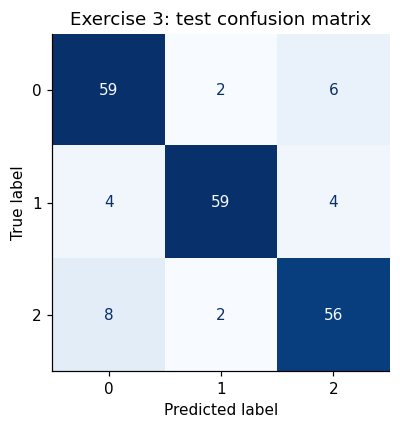

In [12]:
Xe, ye = make_classification(n_samples=1000, n_features=15, n_informative=10,
                              n_redundant=5, n_classes=3, n_clusters_per_class=2,
                              random_state=42)
Xe = pd.DataFrame(Xe)
ye = pd.Series(ye)
print("Shape:", Xe.shape, "| missing:", int(Xe.isna().sum().sum()),
      "| duplicates:", int(Xe.duplicated().sum()))
Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    Xe, ye, test_size=0.2, random_state=42, stratify=ye)
evaluation_model = Pipeline([("scaler", StandardScaler()),
                             ("knn", KNeighborsClassifier(n_neighbors=5))])
evaluation_model.fit(Xe_train, ye_train)
evaluation_pred = evaluation_model.predict(Xe_test)
print("Test accuracy:", round(accuracy_score(ye_test, evaluation_pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(ye_test, evaluation_pred), 4))
print("Macro-F1:", round(f1_score(ye_test, evaluation_pred, average="macro"), 4))
print("Class counts (test):", ye_test.value_counts().sort_index().to_dict())
evaluation_baseline = DummyClassifier(strategy="most_frequent").fit(Xe_train, ye_train)
print("Baseline test accuracy:", round(accuracy_score(ye_test, evaluation_baseline.predict(Xe_test)), 4))
print(classification_report(ye_test, evaluation_pred, zero_division=0))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(ye_test, evaluation_pred, ax=ax,
                                        cmap="Blues", colorbar=False)
ax.set_title("Exercise 3: test confusion matrix")
plt.tight_layout(); plt.show()

### Analisis latihan 3

Accuracy dan macro-F1 merangkum performa dari sudut berbeda; confusion matrix menunjukkan kelas yang tertukar. Tidak tepat membandingkan skor latihan 2 dan 3 sebagai bukti satu hyperparameter lebih baik, karena jumlah fitur dan datasetnya berbeda. Eksperimen perbandingan yang adil memerlukan data serta split yang sama.

## 10. Tambahan — KNN regression

Bagian tambahan ini memperjelas fungsi KNN untuk target kontinu yang disebut pada pengantar buku. Untuk weights uniform, prediksi adalah rata-rata target k tetangga. KNN biasa tidak mengekstrapolasi tren di luar rentang target tetangganya. Contoh menggunakan sinus satu dimensi, k=7 yang ditetapkan sebelumnya, serta baseline rata-rata training.

KNN test MAE: 0.1189
KNN test R²: 0.9639
Baseline test MAE: 0.6975


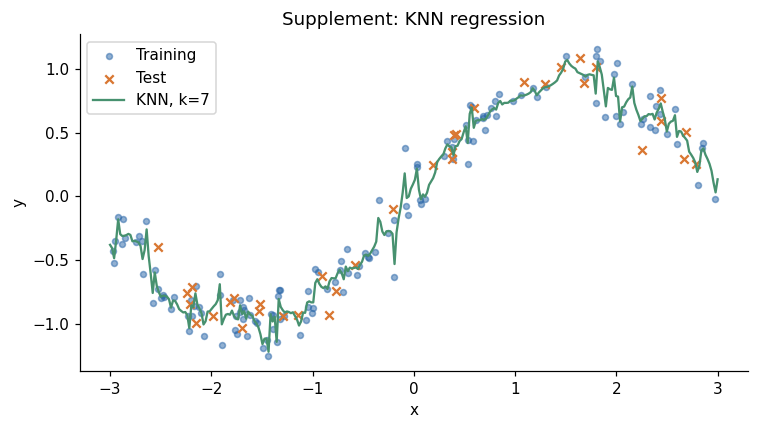

In [13]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score
rng = np.random.default_rng(RANDOM_STATE)
Xr = np.sort(rng.uniform(-3, 3, 180)).reshape(-1, 1)
yr = np.sin(Xr[:,0]) + rng.normal(0, 0.15, len(Xr))
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)
regressor = Pipeline([("scaler",StandardScaler()),
                      ("knn",KNeighborsRegressor(n_neighbors=7, weights="distance"))])
regressor.fit(Xr_train, yr_train)
reg_pred = regressor.predict(Xr_test)
reg_baseline = DummyRegressor().fit(Xr_train, yr_train)
print("KNN test MAE:", round(mean_absolute_error(yr_test, reg_pred), 4))
print("KNN test R²:", round(r2_score(yr_test, reg_pred), 4))
print("Baseline test MAE:", round(mean_absolute_error(yr_test, reg_baseline.predict(Xr_test)), 4))
plot_x = np.linspace(-3, 3, 300).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(Xr_train[:,0], yr_train, s=15, alpha=0.5, color=COLORS[0], label="Training")
ax.scatter(Xr_test[:,0], yr_test, s=30, marker="x", color=COLORS[1], label="Test")
ax.plot(plot_x[:,0], regressor.predict(plot_x), color=COLORS[2], label="KNN, k=7")
ax.set(xlabel="x", ylabel="y", title="Supplement: KNN regression")
ax.legend(); plt.tight_layout(); plt.show()

## Catatan hasil eksekusi

Pada eksekusi yang disertakan (4 Oktober 2026), KNN Iris memperoleh akurasi test **93,33%**, lebih rendah daripada CV terbaik **97,50%**. Nested CV pada data training memiliki rerata sekitar **95,83%**; hasil ini mengingatkan bahwa CV bukan jaminan skor test. Pada Breast Cancer, akurasi **95,61%** disertai recall malignant **92,86%**: masih ada **3 dari 42** kasus malignant yang terlewat. Karena itu akurasi saja tidak cukup untuk membaca hasil klasifikasi ini.

Perbedaan versi pustaka dapat menghasilkan sedikit perubahan angka.

## 11. Ringkasan dan kesimpulan

| Konsep | Peran | Hal yang harus dijaga |
|---|---|---|
| k | Ukuran lingkungan prediksi | k terlalu kecil sensitif noise; k terlalu besar bisa underfit |
| Distance metric | Menentukan arti dekat | p=2 Minkowski identik dengan Euclidean |
| Scaling | Mengubah kontribusi fitur pada jarak | Fit hanya pada training/fold melalui pipeline |
| GridSearchCV | Memilih parameter dari training CV | Test tidak digunakan untuk seleksi |
| Nested CV | Mengevaluasi prosedur tuning | Outer fold tidak boleh ikut inner search |
| Learning curve | Diagnosis pengaruh jumlah data | Kurva setelah tuning bersifat deskriptif |
| Confusion matrix | Menunjukkan jenis kesalahan | Periksa urutan label, support, dan orientasi sumbu |
| KNN regression | Merata-ratakan target tetangga | Lemah untuk ekstrapolasi tren |

**Kesimpulan:** kualitas KNN bergantung pada representasi fitur dan definisi jarak. Scaling, pemilihan k, dan weights harus dinilai pada data training melalui CV. Hasil akhir perlu dibandingkan dengan baseline dan dilengkapi analisis per kelas. Skor tinggi pada benchmark kecil tidak menjamin performa pada populasi lain atau dimensi yang lebih besar.

### Pertanyaan refleksi

1. Mengapa hasil Minkowski p=2 sama dengan Euclidean?
2. Mengapa scaler sebelum GridSearchCV dapat membocorkan informasi antar-fold?
3. Mengapa recall malignant perlu menyebut positive label=0?
4. Mengapa 100% accuracy pada kelas setosa tidak cukup membuktikan overfitting?

## 12. Referensi

1. John Sukup, *scikit-learn Cookbook*, 3rd ed., Packt, 2025, Chapter 4.
2. [Notebook dan exercise solution resmi](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/main/Chapter_4).
3. [scikit-learn: Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html).
4. [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), [learning curves](https://scikit-learn.org/stable/modules/learning_curve.html), dan [nested CV](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html).
5. [Classification metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics) dan [common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html).

Kode merupakan reproduksi/adaptasi beratribusi. Bantuan LLM digunakan untuk menyusun penjelasan dan memeriksa kode. Refleksi pribadi perlu ditulis mahasiswa setelah memahami hasil.